<a href="https://colab.research.google.com/github/prabuddhayogi/ai-with-python/blob/CNN/CnnBook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install matplotlib
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

Loading the MNIST Dataset
TensorFlow provides MNIST directly through Keras.

Dataset structure:

X_train → training images
y_train → training labels

X_test → testing images
y_test → testing labels

In [2]:
from tensorflow.keras.datasets import mnist

(X_train, y_train), (X_test, y_test) = mnist.load_data()

print("Training images shape:", X_train.shape)
print("Testing images shape:", X_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training images shape: (60000, 28, 28)
Testing images shape: (10000, 28, 28)


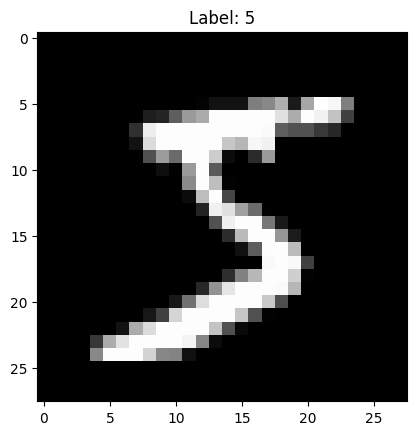

In [3]:
plt.imshow(X_train[0], cmap='gray')
plt.title("Label: {}".format(y_train[0]))
plt.show()

In [4]:
X_train = X_train.reshape(-1,28,28,1)
X_test = X_test.reshape(-1,28,28,1)
# In the MNIST dataset, each pixel value represents the intensity of a grayscale pixel.
# These pixel values range from **0 to 255**.

# - 0 represents **black**
# - 255 represents **white**
# - Values in between represent different shades of gray
# in short we are doing normalization
X_train = X_train / 255.0
X_test = X_test / 255.0

In [5]:
# imported model
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

CNN Model Architecture Explanation
In this step, we defined a Convolutional Neural Network (CNN) model using a sequential architecture. The layers are arranged in order so that the output of one layer becomes the input of the next layer.

The model begins with a convolution layer with 32 filters of size 3×3, which scans the input image to detect simple patterns such as edges and small shapes. The ReLU activation function is applied to introduce non-linearity.

Next, a max pooling layer with a 2×2 window is used to reduce the spatial dimensions of the feature map while preserving the most important features.

A second convolution layer with 64 filters is added to learn more complex patterns from the previous feature maps. This is followed again by a max pooling layer to further reduce dimensionality.

After feature extraction, the Flatten layer converts the multi-dimensional feature maps into a one-dimensional vector so that it can be processed by fully connected layers.

The Dense layer with 128 neurons learns higher-level representations of the extracted features.

Finally, the output layer with 10 neurons and Softmax activation produces probability scores for the 10 digit classes (0–9), and the class with the highest probability is chosen as the prediction.`

In [6]:
model = Sequential([

    Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),

    MaxPooling2D((2,2)),

    Conv2D(64, (3,3), activation='relu'),

    MaxPooling2D((2,2)),

    Flatten(),

    Dense(128, activation='relu'),

    Dense(10, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Summary
The CNN model learns parameters mainly in the convolution and dense layers. Pooling and flatten layers do not contain trainable parameters. The largest number of parameters appears in the dense layer because it connects every input feature to each neuron in the layer.

In [7]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [9]:
# training the model
history = model.fit(
    X_train,
    y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.1
)

Epoch 1/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 45s 52ms/step - accuracy: 0.9493 - loss: 0.1702 - val_accuracy: 0.9847 - val_loss: 0.0511
Epoch 2/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 40s 48ms/step - accuracy: 0.9842 - loss: 0.0513 - val_accuracy: 0.9860 - val_loss: 0.0445
Epoch 3/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 40s 47ms/step - accuracy: 0.9889 - loss: 0.0343 - val_accuracy: 0.9903 - val_loss: 0.0369
Epoch 4/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 40s 48ms/step - accuracy: 0.9914 - loss: 0.0264 - val_accuracy: 0.9900 - val_loss: 0.0327
Epoch 5/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 40s 48ms/step - accuracy: 0.9931 - loss: 0.0201 - val_accuracy: 0.9902 - val_loss: 0.0356


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step


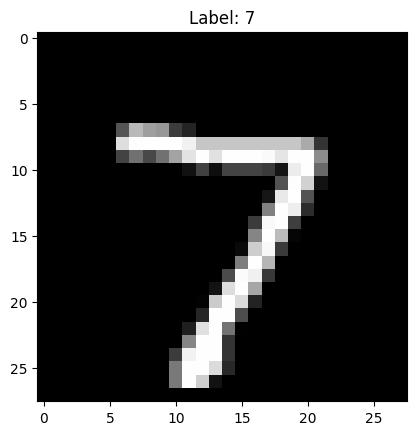

Predicted digit: 7


In [10]:
prediction = model.predict(X_test[:1])

plt.imshow(X_test[0].reshape(28,28), cmap='gray')
plt.title("Label: {}".format(y_test[0]))
plt.show()

print("Predicted digit:", np.argmax(prediction))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 149ms/step


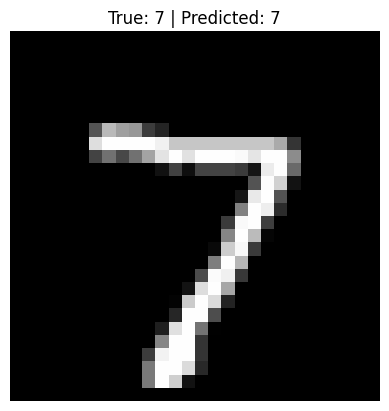

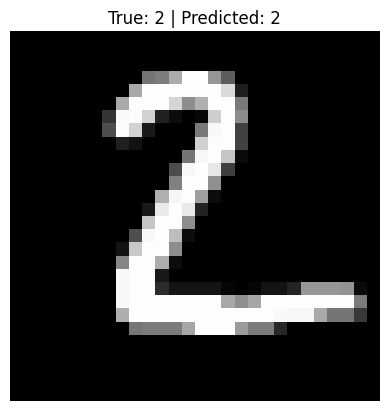

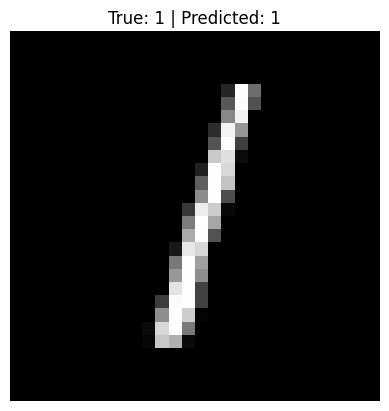

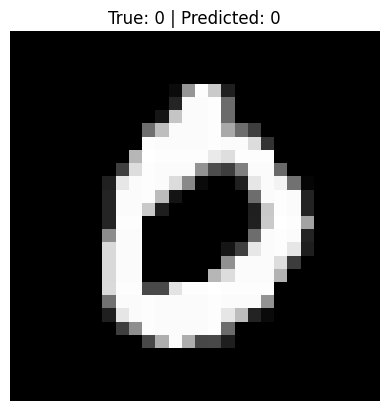

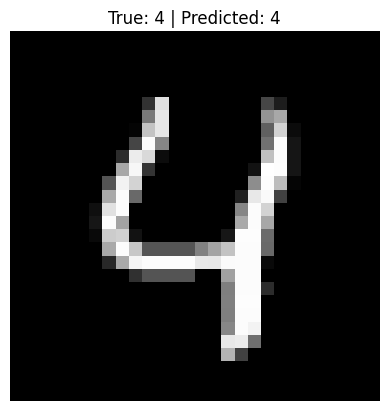

In [11]:
# multiple images

num_images = 5

predictions = model.predict(X_test[:num_images])

for i in range(num_images):

    plt.imshow(X_test[i].reshape(28,28), cmap='gray')
    plt.title(f"True: {y_test[i]} | Predicted: {np.argmax(predictions[i])}")
    plt.axis('off')
    plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step


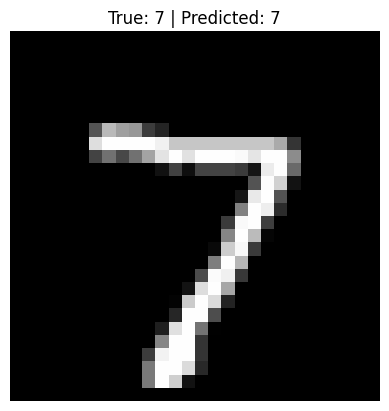

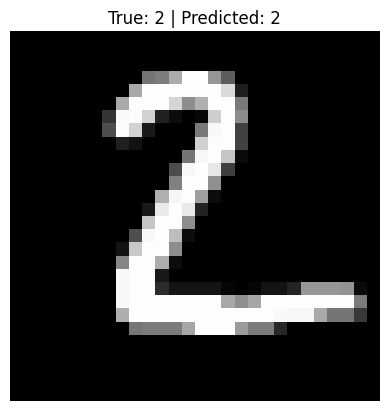

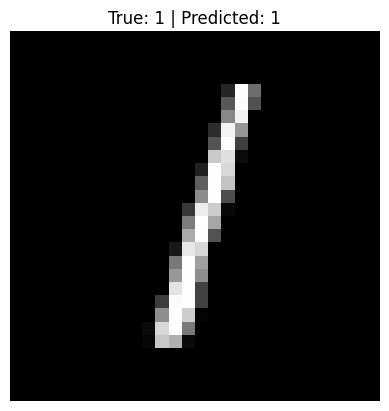

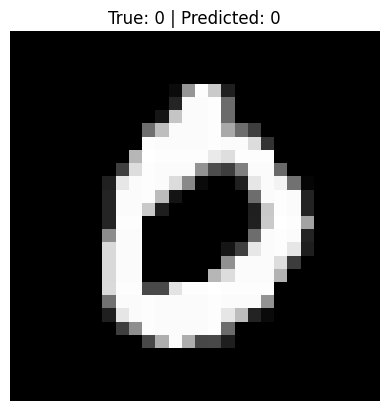

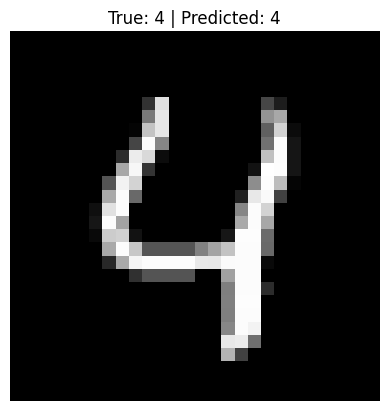

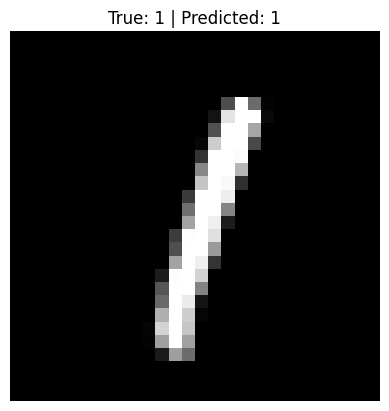

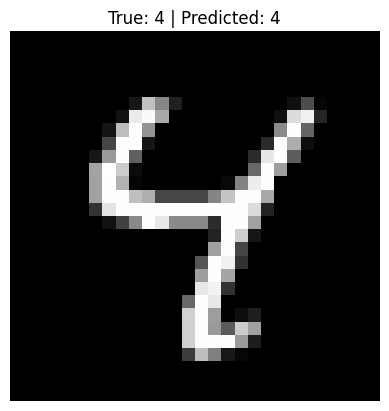

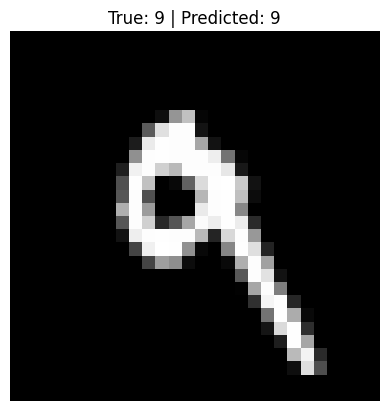

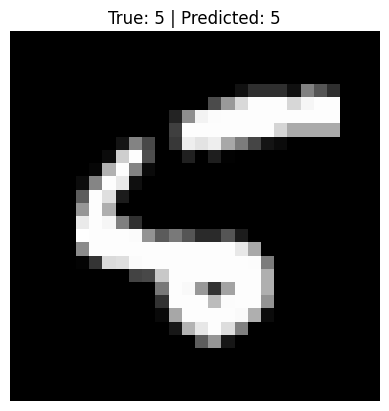

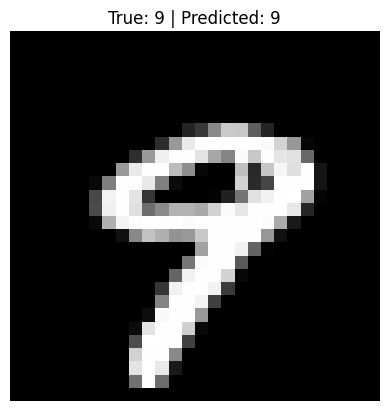

In [13]:
# multiple images

num_images = 10

predictions = model.predict(X_test[:num_images])

for i in range(num_images):

    plt.imshow(X_test[i].reshape(28,28), cmap='gray')
    plt.title(f"True: {y_test[i]} | Predicted: {np.argmax(predictions[i])}")
    plt.axis('off')
    plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
Predicted digit: 2


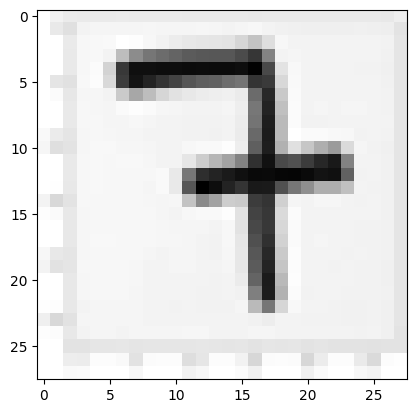

In [14]:
# Test With External Images
from PIL import Image
import numpy as np

img = Image.open("/content/drive/MyDrive/AI-python/lecture37/image_of_7.png").convert("L")
img = img.resize((28,28))

img_array = np.array(img) / 255.0
img_array = img_array.reshape(1,28,28,1)

prediction = model.predict(img_array)

print("Predicted digit:", np.argmax(prediction))

plt.imshow(img_array.reshape(28,28), cmap='gray')
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
Predicted digit for /content/drive/MyDrive/AI-python/lecture37/image_of_0.png: 0


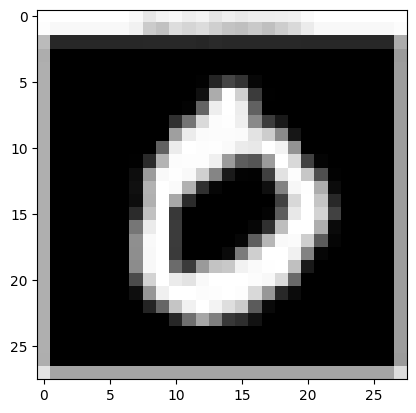

Predicted digit for /content/drive/MyDrive/AI-python/lecture37/image_of_1.png: 1


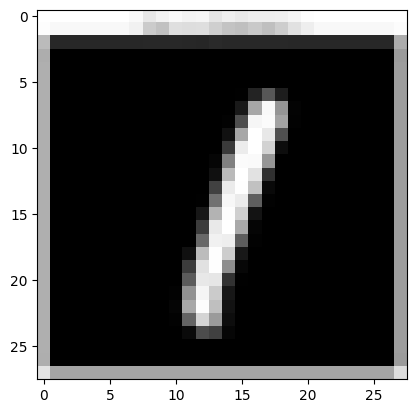

Predicted digit for /content/drive/MyDrive/AI-python/lecture37/image_of_2.png: 2


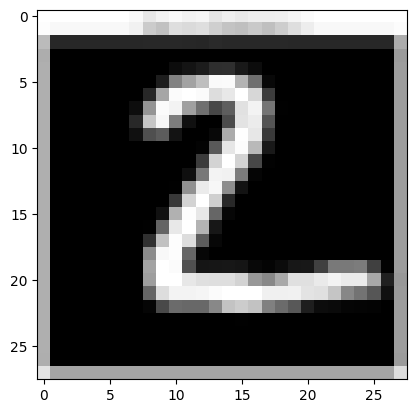

Predicted digit for /content/drive/MyDrive/AI-python/lecture37/image_of_4.png: 4


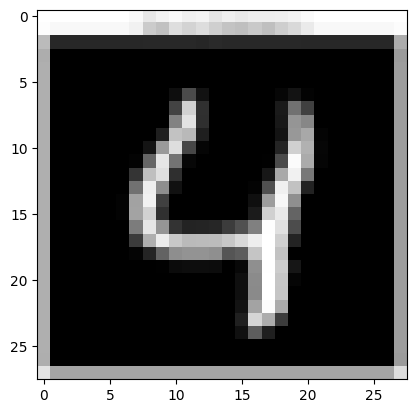

Predicted digit for /content/drive/MyDrive/AI-python/lecture37/image_of_7.png: 2


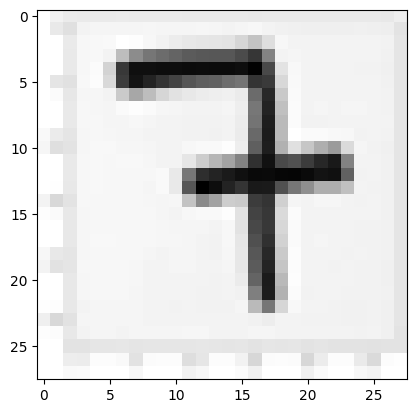

Predicted digit for /content/drive/MyDrive/AI-python/lecture37/image_of_9.png: 9


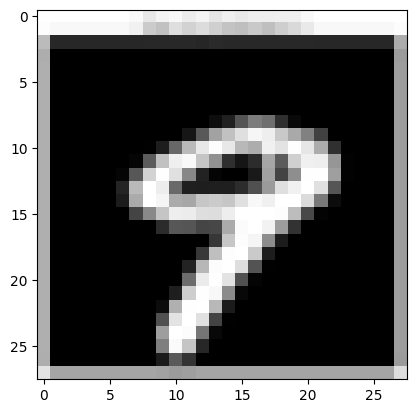

In [16]:
# List of image file paths
image_files = [
    "/content/drive/MyDrive/AI-python/lecture37/image_of_0.png",
    "/content/drive/MyDrive/AI-python/lecture37/image_of_1.png",
    "/content/drive/MyDrive/AI-python/lecture37/image_of_2.png",
    "/content/drive/MyDrive/AI-python/lecture37/image_of_4.png",
    "/content/drive/MyDrive/AI-python/lecture37/image_of_7.png",
    "/content/drive/MyDrive/AI-python/lecture37/image_of_9.png"
]

images = []

# Load and preprocess each image
for file in image_files:
    img = Image.open(file).convert("L")  # convert to grayscale
    img = img.resize((28, 28))           # resize to 28x28
    img_array = np.array(img) / 255.0    # normalize
    img_array = img_array.reshape(28, 28, 1)
    images.append(img_array)

# Convert list to numpy array (batch of 6)
images_batch = np.array(images)

# Predict all 6 images at once
predictions = model.predict(images_batch)

# Print results
for i, pred in enumerate(predictions):
    print(f"Predicted digit for {image_files[i]}: {np.argmax(pred)}")
    plt.imshow(images_batch[i].reshape(28, 28), cmap='gray')
    plt.show()